## Introducción

Como analista de datos, mi mision es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajare con datos reales de TomTom Traffic Index y OECD Cities, que debere limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Procedimiento:**
- Importar las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Cargar los archivos usando `pd.read_csv()`:
- Guardar los DataFrames en las variables `traffic` y `eco`.
- Mostrar las primeras 5 filas de cada DataFrame.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# cargar archivos
traffic = pd.read_csv('tomtom_traffic.csv')
eco = pd.read_csv('oecd_city_economy.csv')

In [3]:
# mostrar las primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [4]:
# mostrar las primeras 5 filas de eco
display(eco.head(5))
print('Paises encontrados en el df eco')
print(eco['Country'].unique())

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


Paises encontrados en el df eco
['Argentina' 'Brazil' 'Chile' 'Colombia' 'Mexico' 'Peru' 'Uruguay']



---

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Procedimiento:**

- Usar `.info()` para conocer la estructura de ambos DataFrames.
- Mostrar los primeros 3 renglones de cada DF.
- Identificar si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
- ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato tienen y cuál deberían de tener?
- ¿Hay datos ausentes en alguna columna?


In [5]:
# Examinar la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- El conjunto contiene más de 1 millón de registros (1,004,464), lo que proporciona una base sólida para detectar patrones, tendencias y diferencias entre ciudades o países con un alto nivel de confianza.
- Todas las columnas tienen el mismo número de registros no nulos, lo que indica que no existen valores faltantes. Esto reduce significativamente el tiempo de preparación y limpieza de datos y aumenta la confiabilidad de los análisis.
- Las variables Country y City permiten segmentar el comportamiento del tráfico por ubicación, facilitando comparaciones entre regiones y la identificación de zonas críticas.
- UpdateTimeUTC y UpdateTimeUTCWeekAgo actualmente son object, pero representan fechas como texto, cambiar formatos a datetime para un buen analisis.
- Variables float64 (8 columnas) Estas columnas ya están en formato numérico y listas para análisis estadístico.

In [6]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:

- El dataset tiene 30 registros y 7 variables, por lo que es pequeño y fácil de manejar.
- No existen valores nulos, lo cual indica buena calidad de datos.
- La columna Year ya tiene el tipo correcto (int64).
- Las variables City GDP/capita, Unemployment %, PM2.5 (µg/m³) y Population (M) están almacenadas como object, aunque deberían ser numéricas.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Procedimiento:**

- Cambiar los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verificar que los cambios se hayan aplicado correctamente usando `.columns`.


In [7]:
# Estandarizar los nombres de las columnas de traffic
traffic.columns = [
    'country',
    'city',
    'update_time_utc',
    'jams_delay',
    'traffic_index_live',
    'jams_length_in_kms',
    'jams_count',
    'traffic_index_week_ago',
    'update_time_utc_week_ago',
    'travel_time_live_per_10kms_mins',
    'travel_time_historic_per_10kms_mins',
    'mins_delay'

]

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [8]:
# Estandarizar los nombres de las columnas de eco
#tu código aquí
eco.columns = [
    'year',
    'city',
    'country',
    'city_gdp_per_capita',
    'unemployment_pct',
    'pm25_ug_m3',
    'population_m'
]

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_per_capita', 'unemployment_pct',
       'pm25_ug_m3', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Procedimiento:**

- Convertir las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crear una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


In [9]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'])
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'])

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

In [10]:
# Limpiar separadores y convertir columnas numéricas en eco
eco['city_gdp_per_capita'] = (
            eco['city_gdp_per_capita'] 
        .astype(str)
        .str.replace('.', '')
        .str.replace(',', '.')
        .astype(float)
 )

eco['unemployment_pct'] = (
            eco['unemployment_pct'] 
        .astype(str)
        .str.replace('%', '')
        .astype(float)
 )

eco['pm25_ug_m3'] = (
            eco['pm25_ug_m3'] 
        .astype(str)
        .str.replace(',', '.')
        .astype(float)
 )

eco['population_m'] = (
            eco['population_m'] 
        .astype(str)
        .str.replace(',', '.')
        .astype(float)
 )

# Calcular la población total en unidades absolutas (Multiplicar * 1000000)
eco['population'] = eco['population_m'] * 1000000
# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 30 non-null     int64  
 1   city                 30 non-null     object 
 2   country              30 non-null     object 
 3   city_gdp_per_capita  30 non-null     float64
 4   unemployment_pct     30 non-null     float64
 5   pm25_ug_m3           30 non-null     float64
 6   population_m         30 non-null     float64
 7   population           30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_per_capita,unemployment_pct,pm25_ug_m3,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0



---

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Procedimiento**

- Como el DataFrame `traffic` no tiene una columna de año, se utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtrar las filas donde el año sea **2024**.
- Utilizar `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [11]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year
# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [12]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos

display(traffic_2024.head())
display(eco_2024.head())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_per_capita,unemployment_pct,pm25_ug_m3,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000.0



---

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Procedimiento**

- Agrupar los datos por `city`, `country` y `year`.
- Calcular el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guardar el resultado como `traffic_city_year_2024`, manteniendo las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [13]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = (
    traffic_2024
    .groupby(['city', 'country', 'year'])
    .agg({
        'jams_delay': 'mean',
        'traffic_index_live': 'mean',
        'jams_length_in_kms': 'mean',
        'jams_count': 'mean',
        'mins_delay': 'mean',
        'travel_time_live_per_10kms_mins': 'mean',
        'travel_time_historic_per_10kms_mins': 'mean'
    })
    .round(2)
    .reset_index()
)
# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.94,15.26,2.20,4.93,0.77,16.27,15.49
1,aachen,DEU,2024,26.73,20.96,3.89,6.60,0.79,13.40,12.60
2,aarhus,DNK,2024,21.20,16.58,2.74,6.11,0.50,15.22,14.72
3,abu-dhabi,ARE,2024,171.16,13.90,24.51,47.27,0.14,9.83,9.69
4,adana,TUR,2024,83.86,22.54,11.83,23.75,1.13,15.88,14.75


Con esta linea podemos ver de manera rapida que paises presentan mayor retraso por trafico

In [14]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.06,34.22,389.24,594.97,1.86,21.81,19.95
352,tokyo,JPN,2024,2152.57,36.81,373.07,518.81,0.70,22.44,21.75
246,new-york,USA,2024,2133.40,28.21,398.23,544.47,1.40,18.51,17.11
200,london,GBR,2024,2050.70,29.23,287.63,471.80,1.33,17.71,16.39
211,manila,PHL,2024,1741.49,66.13,246.86,341.88,2.47,27.13,24.66
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.65,15.43,0.71,1.59,0.63,16.23,15.59
363,uppsala,SWE,2024,4.19,13.94,0.66,1.35,0.50,15.75,15.24
123,fujairah,ARE,2024,4.03,10.91,0.73,1.37,0.19,11.66,11.47
12,almere,NLD,2024,3.63,6.29,0.51,1.06,-0.02,9.47,9.48


La ciudad con el mayor tiempo promedio de tráfico es mexico-city


---

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Procedimiento**
- Seleccionar solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usar `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Unir ambos DataFrames y definir como **claves de unión** a `city` y `year`.
- Mantener solo las ciudades y años presentes en ambos datasets.
- Guardar el resultado en una nueva variable llamada `merged` y mostrar las primeras 5 filas.


In [15]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']

right_cols = ['city','year','city_gdp_per_capita','unemployment_pct','pm25_ug_m3','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = traffic_2024_small.merge(eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar las primeras 5 filas
merged.head(5)


,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_per_capita,unemployment_pct,pm25_ug_m3,population
0,belo-horizonte,BRA,2024,263.05,19.43,44.04,68.81,0.49,18.30,17.82,11124.0,9.5,16.8,6100000.0
1,bogota,COL,2024,1141.55,37.61,140.89,230.57,1.70,24.99,23.29,11442.0,10.0,17.6,11300000.0
2,brasilia,BRA,2024,101.58,11.26,18.34,27.28,0.19,13.34,13.15,16251.0,7.8,12.8,4800000.0
3,buenos-aires,ARG,2024,571.09,17.76,100.29,137.36,0.42,17.91,17.49,18117.0,7.2,14.5,15400000.0
4,curitiba,BRA,2024,183.47,14.95,30.05,46.90,0.14,17.26,17.12,12381.0,8.2,13.5,3700000.0



---

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Procedimiento**
- Usar las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualizar la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualizar la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **comparar ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.

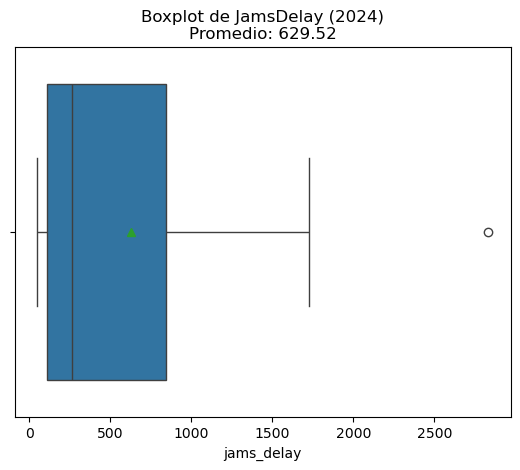

In [16]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
sns.boxplot(data=merged, x="jams_delay", showmeans=True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


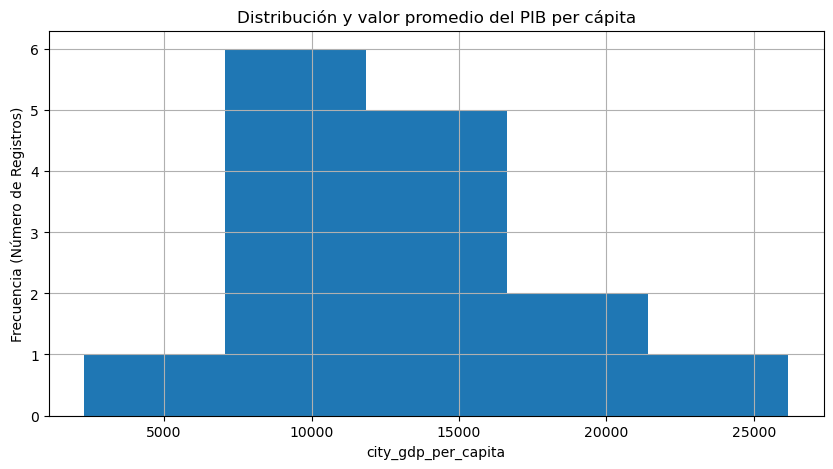

In [17]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
# Generación del Histograma
merged['city_gdp_per_capita'].hist(bins=5, figsize=(10, 5)) # figsize=(ancho, alto)
plt.title('Distribución y valor promedio del PIB per cápita')
plt.xlabel('city_gdp_per_capita')
plt.ylabel('Frecuencia (Número de Registros)')
plt.show()


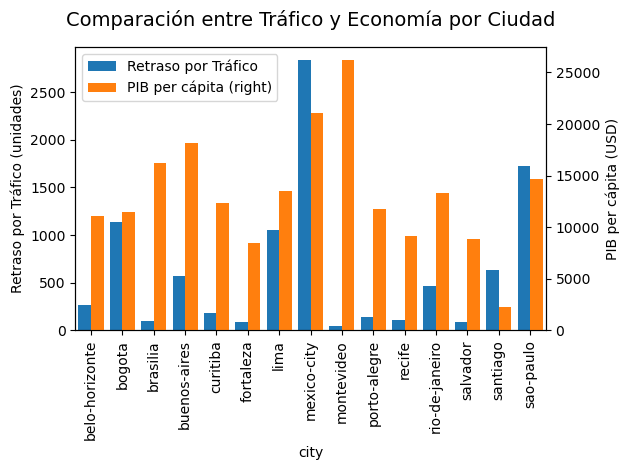

In [18]:
# 1. Renombrar las columnas para que las etiquetas de la leyenda se vean profesionales
df_renamed = merged.rename(columns={
    'jams_delay': 'Retraso por Tráfico',
    'city_gdp_per_capita': 'PIB per cápita'
})

# 2. Crear la base del gráfico con la primera variable (Eje Y izquierdo)
ax = df_renamed.plot(
    kind='bar', 
    x='city', 
    y='Retraso por Tráfico', 
    position=1,       
    width=0.4,        
    color='tab:blue',
    legend=False      # <--- APAGAMOS la leyenda automática aquí
)

# 3. Crear el gráfico para la segunda variable en el eje secundario (Eje Y derecho)
df_renamed.plot(
    kind='bar', 
    x='city', 
    y='PIB per cápita', 
    secondary_y=True, 
    ax=ax,            
    position=0,       
    width=0.4, 
    color='tab:orange',
    legend=False      # <--- APAGAMOS la leyenda automática aquí también
)

# 4. Ajustes estéticos, títulos y etiquetas de los ejes
plt.title('Comparación entre Tráfico y Economía por Ciudad', fontsize=14, pad=15)
ax.set_ylabel('Retraso por Tráfico (unidades)')         
ax.right_ax.set_ylabel('PIB per cápita (USD)')          

# Juntamos las etiquetas de ambos ejes en una sola estructura
lineas_izq, etiquetas_izq = ax.get_legend_handles_labels()
lineas_der, etiquetas_der = ax.right_ax.get_legend_handles_labels()

# Creamos una única leyenda en la esquina superior izquierda (upper left) donde hay espacio libre
ax.legend(lineas_izq + lineas_der, etiquetas_izq + etiquetas_der, loc='upper left')
# ------------------------------------------------

# Ajustar los límites del eje X
ax.set_xlim(-0.5, len(df_renamed) - 0.5)

# Rotar los nombres de las ciudades 90 grados
ax.set_xticklabels(df_renamed['city'], rotation=90)

# Optimizar el espacio
plt.tight_layout()

# Mostrar el gráfico final
plt.show()


**Hallazgos:**

No existe una relacion clara entre el trafico y la economia realmente, sin embargo:

Montevideo: Es, por un margen muy amplio, la ciudad con el mayor PIB per cápita de la muestra (rozando los 26,000). Lo curioso es que su barra de tráfico es muy baja, lo que podría sugerir una economía fuerte con una gestión vial eficiente (o una población/parque automotor más pequeño).

Mexico-city (CDMX): Es el caso de alarma. Tiene el mayor retraso por tráfico de todo el gráfico de forma muy destacada (la barra azul más alta), combinado con el segundo PIB per cápita más alto. Esto indica que es una superpotencia económica en la región, pero sufre de una crisis severa de infraestructura o congestión vial que le cuesta miles de horas a sus habitantes.

El Caso Particular de Santiago
Santiago: Presenta un comportamiento atípico. Su PIB per cápita se muestra extremadamente bajo en comparación con las demás capitales del gráfico (el más bajo de todos, cerca de los 2,500), pero su nivel de tráfico es visiblemente más alto que el de ciudades con mucha más economía como Brasilia o Buenos Aires.

La Tendencia General en Brasil
Ciudades como Sao Paulo y Belo Horizonte muestran niveles de tráfico perceptibles, pero el comportamiento del PIB varía mucho entre regiones (Brasilia y Sao Paulo liderando el bloque brasileño, mientras que Fortaleza y Salvador se quedan rezagados).


---
### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Procedimeinto**

- Exportar el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usar `index=False` para no incluir el índice.


In [19]:
# Exportar el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

# 🧾 Resumen ejecutivo 

## Analisis sobre como impacta el trafico directamente sobre el PIB de las ciudades en latinoamerica (2024)
**Calidad de datos**
- Se normalizo el titulo de todas las comunas a snake_case.
- Ambos datasets presentan anomalias en la estructura de sus respectivas columnas, se implemento formatos y estandarizacion para garantizar  la integridad y trazabiliad de los datos de acuerdo a el diccionario.
- Se reemplazaron simbolos "," y o "." mediante tipo texto para posteriormente convertirlos a float y poder usarlos en calculos.
- Cambio de fecha a datetime para posteriormente extraer el ano a una nueva columna "year" y poder filtrar los datasets.
- Se utilizo INNER join para combinar ambos datasets mediante 'year' y 'city'.

**Cobertura**
- Se filtro para analizar datos con respecto al periodo del 2024
- Cabe destacar que  el dataset "eco" contenia unicamente informacion de paises de LATAM lo cual redujo considerablemente el volumen de datos ya que se uso INNER JOIN
- Al final quedaron un total de 7 paises: 'Argentina' 'Brazil' 'Chile' 'Colombia' 'Mexico' 'Peru' 'Uruguay. Con sus respectivas ciudades:(15 en total)

**Relación entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)**
- La mayoria de los paises presentan una relacion consistente entre el trafico y el PIB
- Existen casos atipicos como lo es la Ciudad de México (CDMX): Es el caso más crítico; presenta el mayor retraso por tráfico de la muestra y el segundo PIB per cápita más alto, lo que evidencia un problema severo de congestión frente a su poder económico.
- Montevideo: Registra, por amplio margen, el mayor PIB per cápita, pero mantiene niveles de tráfico prácticamente imperceptibles, sugiriendo una movilidad eficiente.
- Santiago: Muestra un comportamiento atípico al registrar el PIB per cápita más bajo de todo el gráfico, pero con un nivel de tráfico visiblemente superior al de economías más grandes como Buenos Aires o Brasilia.
- Tendencia en Brasil: Ciudades como Sao Paulo y Brasilia lideran el bloque económico brasileño con tráfico moderado, mientras que Fortaleza y Salvador se quedan rezagadas en ambas métricas.

**Recomendaciones**
- Priorizar Infraestructura de Movilidad en Nodos Críticos (Caso CDMX) Canalizar inversión pública y privada hacia sistemas de transporte masivo de alta capacidad (metros, trenes suburbanos) y optimización de redes viales. Ciudad de México es un motor económico clave (segundo PIB más alto), pero la severa congestión vehicular actúa como un impuesto invisible que reduce la productividad, destruye horas-hombre y frena un potencial de crecimiento aún mayor.

- Auditoría y Corrección de Datos Socioeconómicos (Caso Santiago) Solicitar una revisión técnica urgente de la metodología de captura de datos para la métrica del PIB en el cono sur. Los datos muestran a Santiago con el PIB per cápita más bajo de la muestra, lo cual contradice abiertamente los indicadores macroeconómicos reales de la región. Antes de usar este reporte para decisiones financieras, se debe descartar un error de normalización o de divisas.

- Modelado de Buenas Prácticas (Caso Montevideo) Realizar un estudio de referencia (benchmarking) detallado sobre las políticas de desarrollo urbano, densidad poblacional y transporte de Montevideo. Al ser la ciudad con el mayor PIB per cápita pero con un impacto de tráfico mínimo, representa el escenario ideal de eficiencia. Es necesario entender si este éxito se debe a una planificación urbana replicable o simplemente a su escala demográfica.

- Estrategia de Conectividad Descentralizada para Brasil. Implementar incentivos de descentralización comercial (como el trabajo remoto o parques industriales periféricos) en los centros de alto PIB como Sao Paulo.
El bloque brasileño muestra una disparidad muy marcada; mientras los grandes centros económicos sufren de tráfico perceptible, las regiones del noreste (Fortaleza, Salvador) se quedan rezagadas en economía. Descentralizar aliviaría la presión vial de los motores económicos del país.